     ┌───┐             
q_0: ┤ H ├──■────■───■─
     └───┘┌─┴─┐  │   │ 
q_1: ─────┤ X ├──■───X─
          └───┘┌─┴─┐ │ 
q_2: ──────────┤ X ├─X─
               └───┘   


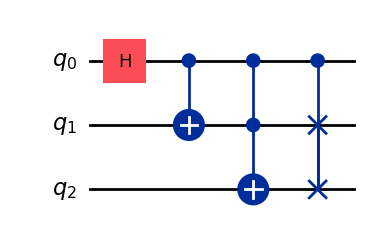

In [1]:
#Exercise 1: Build CNOT Taffoli CSWAP Gate(Multi Qubit gates)

from qiskit import QuantumCircuit
from qiskit.visualization import plot_circuit_layout, plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

# Create a quantum circuit with 3 qubits (enough for Toffoli and Fredkin)
qc = QuantumCircuit(3)

# --- CNOT gate ---
qc.h(0)           # put qubit 0 in superposition
qc.cx(0, 1)       # CNOT with control qubit 0, target qubit 1

# --- Toffoli gate (CCX) ---
qc.ccx(0, 1, 2)   # Toffoli: controls q0, q1; target q2

# --- Fredkin gate (CSWAP) ---
qc.cswap(0, 1, 2) # Fredkin: control q0; swap q1 <-> q2

# Draw the circuit
print(qc)
qc.draw("mpl")


     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
q_2: ──────────
               


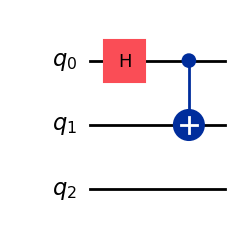

In [2]:
#Exercise 2: Build CNOT  Gate(Multi Qubit gates)


from qiskit import QuantumCircuit
from qiskit.visualization import plot_circuit_layout, plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

# Create a quantum circuit with 3 qubits (enough for Toffoli and Fredkin)
qc = QuantumCircuit(3)

# --- CNOT gate ---
qc.h(0)           # put qubit 0 in superposition
qc.cx(0, 1)       # CNOT with control qubit 0, target qubit 1


print(qc)
qc.draw("mpl")


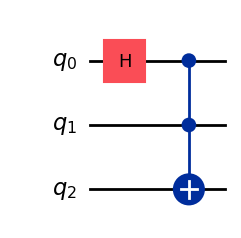

In [7]:
#Exercise 3: Build  Taffoli (Multi Qubit gates)

from qiskit import QuantumCircuit
from qiskit.visualization import plot_circuit_layout, plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

# Create a quantum circuit with 3 qubits (enough for Toffoli and Fredkin)
qc = QuantumCircuit(3)

# --- CNOT gate ---
qc.h(0)           # put qubit 0 in superposition

# --- Toffoli gate (CCX) ---
qc.ccx(0, 1, 2)   # Toffoli: controls q0, q1; target q2


qc.draw("mpl")


     ┌───┐   
q_0: ┤ H ├─■─
     └───┘ │ 
q_1: ──────X─
           │ 
q_2: ──────X─
             


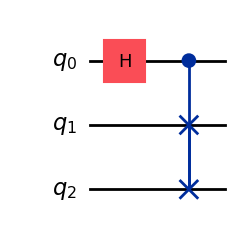

In [6]:
#Exercise 4: Build  CSWAP Gate(Multi Qubit gates)
from qiskit import QuantumCircuit
from qiskit.visualization import plot_circuit_layout, plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

# Create a quantum circuit with 3 qubits (enough for Toffoli and Fredkin)
qc = QuantumCircuit(3)

# --- CNOT gate ---
qc.h(0)           # put qubit 0 in superposition



# --- Fredkin gate (CSWAP) ---
qc.cswap(0, 1, 2) # Fredkin: control q0; swap q1 <-> q2

# Draw the circuit
print(qc)
qc.draw("mpl")


CNOT results: {'00': 487, '11': 537}
Toffoli results: {'111': 1024}
Fredkin results: {'101': 1024}


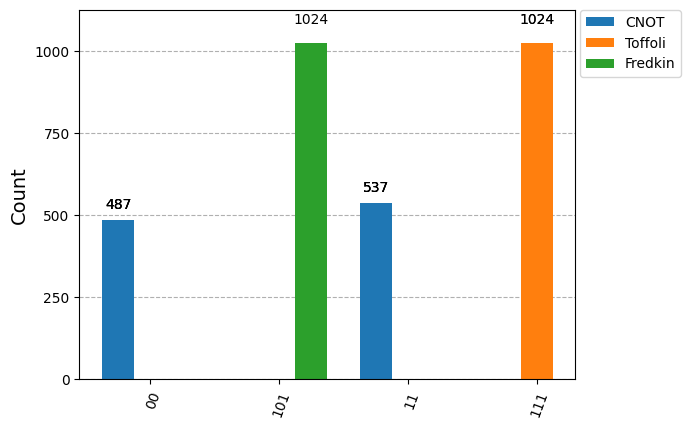

In [12]:
#Exercise 5: Simulation of  CNOT Taffoli CSWAP Gate(Multi Qubit gates)

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Simulator
sim = Aer.get_backend("aer_simulator")

# -------- CNOT --------
qc_cnot = QuantumCircuit(2, 2)
qc_cnot.h(0)          # put qubit 0 in |+>
qc_cnot.cx(0, 1)      # CNOT
qc_cnot.measure([0,1], [0,1])   # measure both
result_cnot = sim.run(transpile(qc_cnot, sim)).result()
counts_cnot = result_cnot.get_counts()

# -------- Toffoli (CCX) --------
qc_toffoli = QuantumCircuit(3, 3)
qc_toffoli.x(0)       # control 1 = |1>
qc_toffoli.x(1)       # control 2 = |1>
qc_toffoli.ccx(0,1,2) # Toffoli
qc_toffoli.measure([0,1,2], [0,1,2])
result_toffoli = sim.run(transpile(qc_toffoli, sim)).result()
counts_toffoli = result_toffoli.get_counts()

# -------- Fredkin (CSWAP) --------
qc_fredkin = QuantumCircuit(3, 3)
qc_fredkin.x(0)       # control qubit = |1>
qc_fredkin.x(1)       # target 1 = |1>
# target 2 = |0> (default)
qc_fredkin.cswap(0,1,2)
qc_fredkin.measure([0,1,2], [0,1,2])
result_fredkin = sim.run(transpile(qc_fredkin, sim)).result()
counts_fredkin = result_fredkin.get_counts()

# -------- Display results --------
print("CNOT results:", counts_cnot)
print("Toffoli results:", counts_toffoli)
print("Fredkin results:", counts_fredkin)

# Plot histograms
plot_histogram([counts_cnot, counts_toffoli, counts_fredkin],
               legend=["CNOT", "Toffoli", "Fredkin"])


CNOT results: {'11': 534, '00': 490}
Toffoli results: {'111': 1024}
Fredkin results: {'101': 1024}


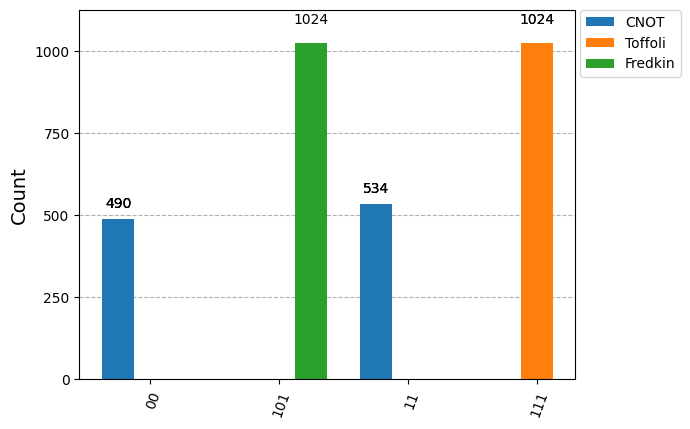

In [13]:
#Exercise 5: Simulation of  CNOT Taffoli CSWAP Gate(Multi Qubit gates)

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# Create simulator
sim = AerSimulator()

# -------- CNOT --------
qc_cnot = QuantumCircuit(2, 2)
qc_cnot.h(0)              # put qubit 0 in |+>
qc_cnot.cx(0, 1)          # CNOT
qc_cnot.measure([0,1], [0,1])
t_cnot = transpile(qc_cnot, sim)
result_cnot = sim.run(t_cnot).result()
counts_cnot = result_cnot.get_counts()

# -------- Toffoli (CCX) --------
qc_toffoli = QuantumCircuit(3, 3)
qc_toffoli.x(0)           # control 1 = |1>
qc_toffoli.x(1)           # control 2 = |1>
qc_toffoli.ccx(0,1,2)     # Toffoli
qc_toffoli.measure([0,1,2], [0,1,2])
t_toffoli = transpile(qc_toffoli, sim)
result_toffoli = sim.run(t_toffoli).result()
counts_toffoli = result_toffoli.get_counts()

# -------- Fredkin (CSWAP) --------
qc_fredkin = QuantumCircuit(3, 3)
qc_fredkin.x(0)           # control qubit = |1>
qc_fredkin.x(1)           # target 1 = |1>, target 2 = |0>
qc_fredkin.cswap(0,1,2)   # Fredkin
qc_fredkin.measure([0,1,2], [0,1,2])
t_fredkin = transpile(qc_fredkin, sim)
result_fredkin = sim.run(t_fredkin).result()
counts_fredkin = result_fredkin.get_counts()

# -------- Display results --------
print("CNOT results:", counts_cnot)
print("Toffoli results:", counts_toffoli)
print("Fredkin results:", counts_fredkin)

# Plot histograms
plot_histogram([counts_cnot, counts_toffoli, counts_fredkin],
               legend=["CNOT", "Toffoli", "Fredkin"])



In [1]:

#Exercise 6: Simulation of  CNOT Taffoli CSWAP Gate(Multi Qubit gates) code using this updated AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

# -------- CNOT (before measurement) --------
qc_cnot = QuantumCircuit(2)
qc_cnot.h(0)          # |+0>
qc_cnot.cx(0, 1)      # CNOT
state_cnot = Statevector.from_instruction(qc_cnot)
print("CNOT statevector:", state_cnot)

# -------- Toffoli (before measurement) --------
qc_toffoli = QuantumCircuit(3)
qc_toffoli.x(0)       # control 1 = 1
qc_toffoli.x(1)       # control 2 = 1
qc_toffoli.ccx(0,1,2) # Toffoli
state_toffoli = Statevector.from_instruction(qc_toffoli)
print("Toffoli statevector:", state_toffoli)

# -------- Fredkin (before measurement) --------
qc_fredkin = QuantumCircuit(3)
qc_fredkin.x(0)       # control = 1
qc_fredkin.x(1)       # target 1 = 1
qc_fredkin.cswap(0,1,2)
state_fredkin = Statevector.from_instruction(qc_fredkin)
print("Fredkin statevector:", state_fredkin)


CNOT statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Toffoli statevector: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))
Fredkin statevector: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


In [ ]:
#outcome of all gates
#do not execute this cell
CNOT: Produces entangled state

1/sqrt(2)[(∣00⟩+∣11⟩)]

Toffoli: Input |110⟩ → target flips → |111⟩

Fredkin: Input |110⟩ → swap targets → |101⟩

Would you like me to also plot these states (Bloch spheres or Hinton diagrams) so you can see the superpositions, not just print amplitudes?

In [15]:
#Statevector simulation (before measurement)
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_hinton, plot_state_qsphere
import matplotlib.pyplot as plt

# -------- CNOT --------
qc_cnot = QuantumCircuit(2)
qc_cnot.h(0)
qc_cnot.cx(0, 1)
state_cnot = Statevector.from_instruction(qc_cnot)

print("CNOT statevector:", state_cnot)
plot_bloch_multivector(state_cnot)      # Bloch spheres
plt.show()
plot_state_hinton(state_cnot)           # Hinton diagram
plt.show()
plot_state_qsphere(state_cnot)          # Q-sphere
plt.show()

# -------- Toffoli --------
qc_toffoli = QuantumCircuit(3)
qc_toffoli.x(0)
qc_toffoli.x(1)
qc_toffoli.ccx(0,1,2)
state_toffoli = Statevector.from_instruction(qc_toffoli)

print("Toffoli statevector:", state_toffoli)
plot_bloch_multivector(state_toffoli)
plt.show()
plot_state_hinton(state_toffoli)
plt.show()
plot_state_qsphere(state_toffoli)
plt.show()

# -------- Fredkin --------
qc_fredkin = QuantumCircuit(3)
qc_fredkin.x(0)
qc_fredkin.x(1)
qc_fredkin.cswap(0,1,2)
state_fredkin = Statevector.from_instruction(qc_fredkin)

print("Fredkin statevector:", state_fredkin)
plot_bloch_multivector(state_fredkin)
plt.show()
plot_state_hinton(state_fredkin)
plt.show()
plot_state_qsphere(state_fredkin)
plt.show()


CNOT statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Toffoli statevector: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))
Fredkin statevector: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


C:\Users\Mukta\AppData\Local\Temp\ipykernel_17676\3642953623.py:19: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape(h, w, 3)
C:\Users\Mukta\AppData\Local\Temp\ipykernel_17676\3642953623.py:19: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape(h, w, 3)
C:\Users\Mukta\AppData\Local\Temp\ipykernel_17676\3642953623.py:19: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape(h, w, 3)
C:\Users\Mukta\AppData\Local\Temp\ipykernel_17676\3642953623.py:19: Matpl

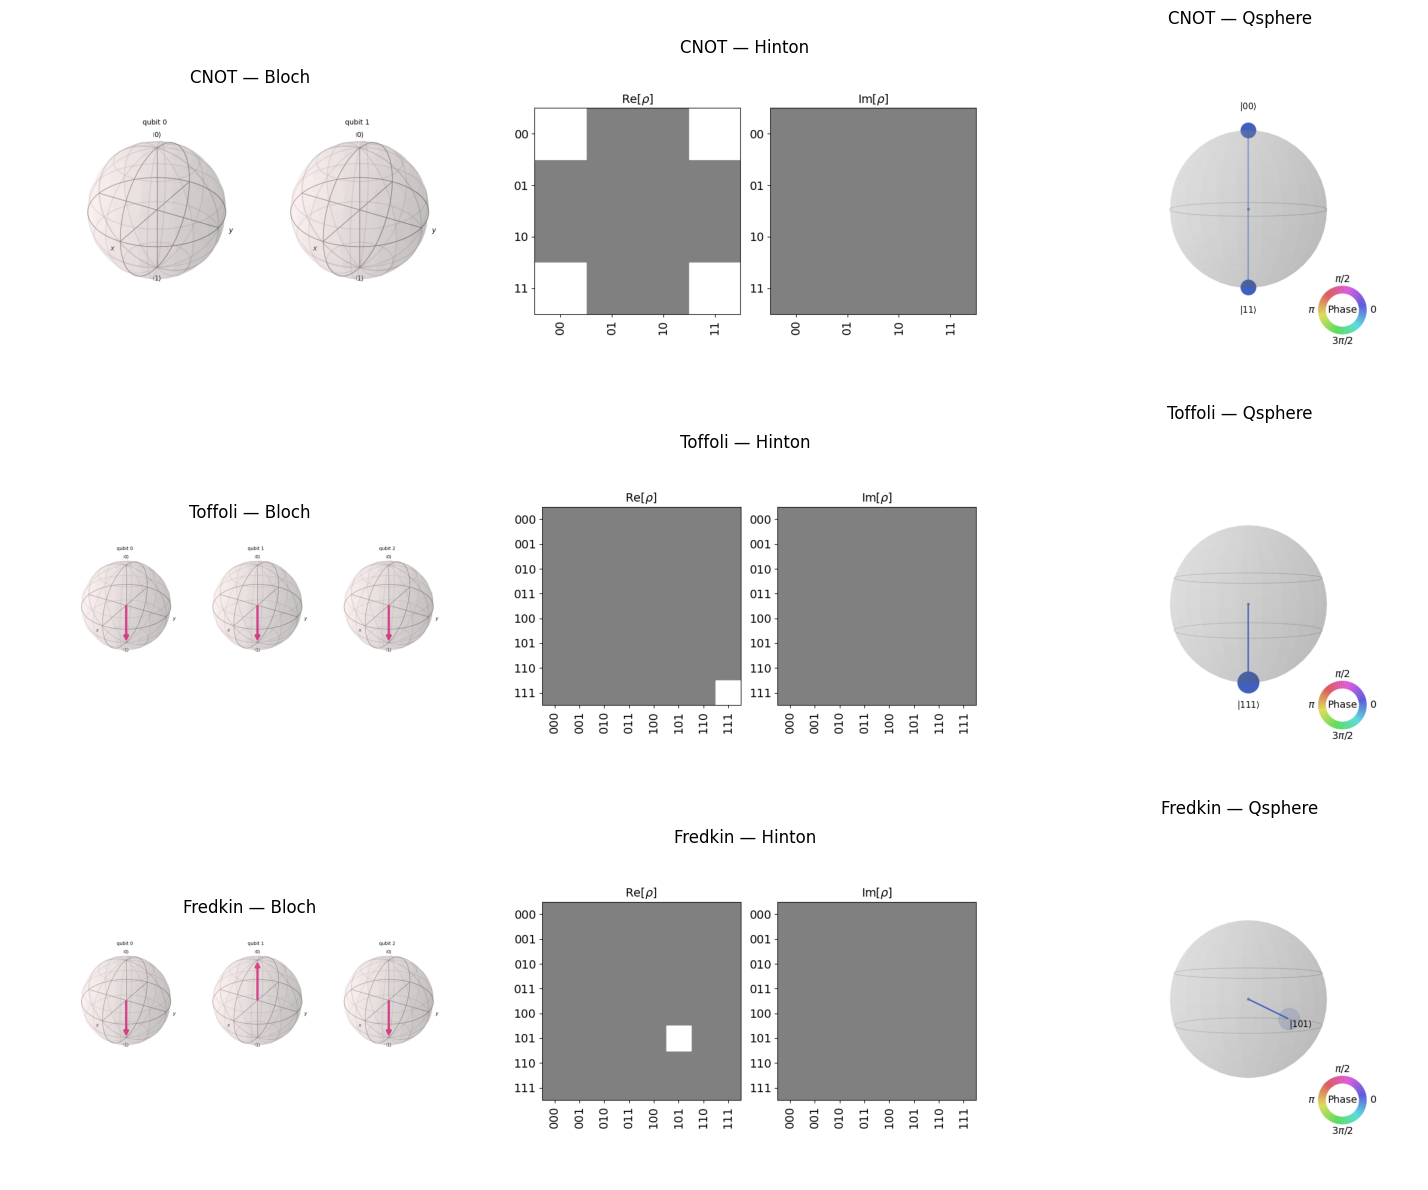

In [17]:
#Plot these states (Bloch spheres or Hinton diagrams)and combine these visualizations into a single figure

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_hinton,
    plot_state_qsphere,
)

def fig_to_image(fig):
    """Render a matplotlib Figure to a HxWx3 uint8 RGB numpy array and close the fig."""
    # Ensure the figure has a canvas
    FigureCanvas(fig)
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8').reshape(h, w, 3)
    plt.close(fig)
    return img

def plot_func_to_image(plot_func, state, **kwargs):
    """
    Call a qiskit plot function which returns a matplotlib Figure,
    convert it to an image array, and return the image.
    """
    fig = plot_func(state, **kwargs)   # plot_func returns a matplotlib Figure
    return fig_to_image(fig)

# --- Prepare the quantum states ---
# CNOT (2 qubits)
qc_cnot = QuantumCircuit(2)
qc_cnot.h(0)
qc_cnot.cx(0, 1)
state_cnot = Statevector.from_instruction(qc_cnot)

# Toffoli (3 qubits)
qc_toffoli = QuantumCircuit(3)
qc_toffoli.x(0)
qc_toffoli.x(1)
qc_toffoli.ccx(0, 1, 2)
state_toffoli = Statevector.from_instruction(qc_toffoli)

# Fredkin (3 qubits)
qc_fredkin = QuantumCircuit(3)
qc_fredkin.x(0)
qc_fredkin.x(1)
qc_fredkin.cswap(0, 1, 2)
state_fredkin = Statevector.from_instruction(qc_fredkin)

# --- Render components to images ---
# CNOT images
img_bloch_cnot = plot_func_to_image(plot_bloch_multivector, state_cnot)
img_hinton_cnot = plot_func_to_image(plot_state_hinton, state_cnot)
img_qsphere_cnot = plot_func_to_image(plot_state_qsphere, state_cnot)

# Toffoli images
img_bloch_toffoli = plot_func_to_image(plot_bloch_multivector, state_toffoli)
img_hinton_toffoli = plot_func_to_image(plot_state_hinton, state_toffoli)
img_qsphere_toffoli = plot_func_to_image(plot_state_qsphere, state_toffoli)

# Fredkin images
img_bloch_fredkin = plot_func_to_image(plot_bloch_multivector, state_fredkin)
img_hinton_fredkin = plot_func_to_image(plot_state_hinton, state_fredkin)
img_qsphere_fredkin = plot_func_to_image(plot_state_qsphere, state_fredkin)

# --- Compose final figure (3 rows x 3 cols) ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Row 0: CNOT
axes[0, 0].imshow(img_bloch_cnot);  axes[0, 0].axis('off'); axes[0, 0].set_title('CNOT — Bloch')
axes[0, 1].imshow(img_hinton_cnot); axes[0, 1].axis('off'); axes[0, 1].set_title('CNOT — Hinton')
axes[0, 2].imshow(img_qsphere_cnot); axes[0, 2].axis('off'); axes[0, 2].set_title('CNOT — Qsphere')

# Row 1: Toffoli
axes[1, 0].imshow(img_bloch_toffoli);  axes[1, 0].axis('off'); axes[1, 0].set_title('Toffoli — Bloch')
axes[1, 1].imshow(img_hinton_toffoli); axes[1, 1].axis('off'); axes[1, 1].set_title('Toffoli — Hinton')
axes[1, 2].imshow(img_qsphere_toffoli); axes[1, 2].axis('off'); axes[1, 2].set_title('Toffoli — Qsphere')

# Row 2: Fredkin
axes[2, 0].imshow(img_bloch_fredkin);  axes[2, 0].axis('off'); axes[2, 0].set_title('Fredkin — Bloch')
axes[2, 1].imshow(img_hinton_fredkin); axes[2, 1].axis('off'); axes[2, 1].set_title('Fredkin — Hinton')
axes[2, 2].imshow(img_qsphere_fredkin); axes[2, 2].axis('off'); axes[2, 2].set_title('Fredkin — Qsphere')

plt.tight_layout()
plt.show()


In [ ]:
#Qiskit code with applications
#build Qiskit code with applications
#Task submission w.r.t. Practical 5

Dear Students, Attempt the following example and submit practical 5

Exercise: Expand the Toffoli example into a full adder circuit in Qiskit

Write code for mentioned example

Circuit Diagram:
Simulation:
Inputs: A = 1, B = 1, Cin = 1
Expected output: 11 -> Sum = 1, Cout = 1
Results:
 {'11': 1024}
Histogram:


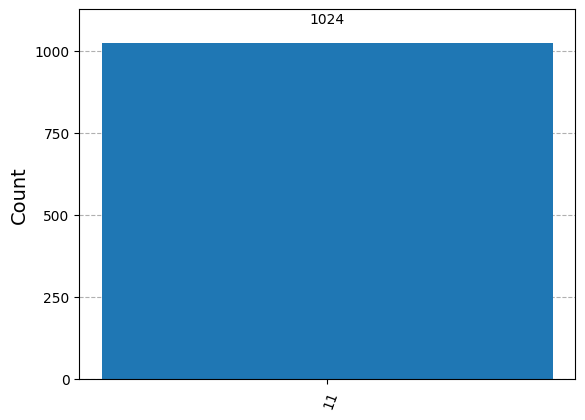

In [3]:
# Create 5 qubit, 2 classical bit circuit
# q0 = A, q1 = B, q2 = Cin (carry in), q3 = Sum, q4 = Cout (carry out)
qc = QuantumCircuit(5, 2)

# Initialize inputs
# Set A=1, B=1, Cin=1
qc.x(0)  # A = 1
qc.x(1)  # B = 1
qc.x(2)  # Cin = 1

# Compute Sum using CNOT gates
# Sum = A XOR B XOR Cin
qc.cx(0, 3) # Sum = A
qc.cx(1, 3) # Sum = A XOR B
qc.cx(2, 3) # Sum = A XOR B XOR Cin

# Compute Cout using Toffoli gates
# Cout = AB + ACin + BCin
qc.ccx(0, 1, 4)  # Cout = AB
qc.ccx(0, 2, 4)  # Cout = AB + ACin
qc.ccx(1, 2, 4)  # Cout = AB + ACin + BCin

qc.barrier()

# Measure outputs
qc.measure(3, 0)  # SUM -> classical bit 0
qc.measure(4, 1)  # CARRY -> classical bit 1

# Draw circuit
print("Circuit Diagram:")
qc.draw("mpl")

simulator = AerSimulator()
result = simulator.run(qc).result()
counts = result.get_counts()

print("Simulation:")
print("Inputs: A = 1, B = 1, Cin = 1")
print("Expected output: 11 -> Sum = 1, Cout = 1")
print("Results:\n", counts)

print("Histogram:")
plot_histogram(counts)